# Portfolio Allocation Across the Case Studies

**Docker image**: `ml4t`

The previous notebook traced the journey from signals to strategies. Here we
isolate the allocator layer: the same forecasts are routed through equal
weight, inverse-vol, MVO, risk parity, and score-weighted allocators in each
of the eight case studies that carry an allocation-stage spine (NASDAQ-100's
pinned carrier is a signal-stage slot strategy with no allocation-stage
sweep, so it drops out of this comparison). The resulting Sharpe spread
quantifies how much room the allocator has to add or subtract value once the
signal is fixed.

**Learning Objectives**:
- Compare allocator performance across diverse asset classes and frequencies
- Identify when allocation amplifies signal vs when signal is too weak to matter
- Examine the spread between best and worst allocators per case study

**Book Reference**: Chapter 20, Section 20.5 (Portfolio Allocation Across the Case Studies)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.
Each case study's registry must contain Ch17 allocation-stage backtests.

In [1]:
"""Ch20 Portfolio Allocation — spine-pinned allocator comparison across 8 case studies.

The Table 20.6 / Figure 20.7 semantics are: hold the highest-validation-Sharpe
signal carrier fixed per case study, then compare allocators at the allocation
stage only, so the best-minus-worst spread measures what the allocator alone
contributes (risk overlays are a downstream layer covered in §20.7). This
matches the caption "rank-1 signal held fixed" and the spine-pinning logic in
``case_studies.utils.strategy_analysis.build_all_synthesis``.
"""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    SHORT_NAMES,
    extract_allocator,
    load_chapter_backtests,
)
from utils.paths import get_chapter_dir

warnings.filterwarnings("ignore")

In [2]:
MAX_CASE_STUDIES = 0  # 0 = all

In [3]:
CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS


def extract_top_k(spec_json: str) -> int:
    """Extract top_k from backtest spec."""
    spec = json.loads(spec_json)
    return spec.get("allocation", {}).get("top_k", 0) or spec.get("signal", {}).get("top_k", 0)

## Load Allocation Results from Registry

Ch17 backtests compare different allocation methods (equal weight, inverse
vol, MVO, risk parity, score-weighted, HRP) while holding the signal
constant. We load the `stage: "allocation"` runs and restrict to the spine
prediction_hash per case study so the comparison reads as
"best within the highest-validation-Sharpe signal carrier".

In [4]:
# Spine prediction hash per case study — read from the synthesis carrier
# file produced by 01_aggregate_synthesis. backtest_comparison.parquet is
# the canonical Ch20 artifact that records spine_prediction_hash per CS.
_spine_df = pl.read_parquet(get_chapter_dir(20) / "output" / "backtest_comparison.parquet").select(
    "case_study_id", "spine_prediction_hash"
)
SPINE_BY_CS = dict(
    zip(
        _spine_df["case_study_id"].to_list(),
        _spine_df["spine_prediction_hash"].to_list(),
        strict=False,
    )
)

# Fail loudly if a requested case study has no spine in the carrier file —
# otherwise SPINE_BY_CS.get() below silently returns None and the CS drops
# out of the comparison without explanation.
_missing_spine = [cs for cs in CS_LIST if cs not in SPINE_BY_CS]
if _missing_spine:
    msg = (
        f"No spine_prediction_hash in backtest_comparison.parquet for: "
        f"{_missing_spine}. Re-run 01_aggregate_synthesis to refresh the carrier."
    )
    raise RuntimeError(msg)

# This section isolates the allocator layer: the signal is held fixed and only
# the allocation method varies. Load the allocation stage ONLY — a trailing-stop
# or other risk overlay (ch19) is a downstream layer, and including its Sharpe
# would credit the allocator with work the overlay did, contradicting the
# "allocator alone" measurement. The "max across rebalance and top-K variants"
# in Table 20.6 is taken over allocation-stage variants, not over overlays.
combined_raw = load_chapter_backtests(
    "ch17",
    case_studies=CS_LIST,
    metrics=[
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
        "cagr",
        "volatility",
        "num_trades",
        "win_rate",
    ],
)

if combined_raw.is_empty():
    msg = "No allocation-stage backtest results found across case studies"
    raise RuntimeError(msg)

# Pin to spine prediction_hash per case study.
spine_filter = pl.struct(["case_study", "prediction_hash"]).map_elements(
    lambda row: row["prediction_hash"] == SPINE_BY_CS.get(row["case_study"]),
    return_dtype=pl.Boolean,
)
combined = combined_raw.filter(spine_filter)

# Extract allocator method and top_k from spec_json
comparison = (
    combined.with_columns(
        allocator=pl.col("spec_json").map_elements(extract_allocator, return_dtype=pl.Utf8),
        top_k=pl.col("spec_json").map_elements(extract_top_k, return_dtype=pl.Int64),
    )
    .filter(
        pl.col("allocator").is_in(
            [
                "equal_weight",
                "inverse_vol",
                "score_weighted",
                "mvo_ledoit_wolf",
                "risk_parity",
                "hrp",
                "conformal_weighted",
            ]
        )
    )
    .select(
        "case_study",
        pl.col("case_study").replace(SHORT_NAMES).alias("display_name"),
        "label",
        "allocator",
        "top_k",
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
        "cagr",
        "volatility",
        "num_trades",
    )
)

# Collapse to one row per (case_study, allocator) — keep the configuration
# (rebalance / top_k / overlay) that posts the highest Sharpe. Table 20.6
# entries are the "best for that allocator" within the spine carrier.
comparison = comparison.sort("sharpe", descending=True).unique(
    subset=["case_study", "allocator"], keep="first"
)

n_cs = comparison["case_study"].n_unique()
print(
    f"Allocators × case studies (spine-pinned): {len(comparison)} rows across {n_cs} case studies"
)
comparison.head(10)

Allocators × case studies (spine-pinned): 51 rows across 8 case studies


case_study,display_name,label,allocator,top_k,sharpe,sortino,total_return,max_drawdown,cagr,volatility,num_trades
str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""crypto_perps_funding""","""Crypto""","""fwd_ret_24h""","""conformal_weighted""",0,2.409716,2.875201,4.28767,-0.243374,1.30476,0.37556,3031.0
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""hrp""",0,0.168183,0.143037,-0.795716,-0.989344,-0.553049,1.298605,null
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""risk_parity""",0,0.149057,0.121645,-0.943803,-0.996471,-0.767698,1.49832,null
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""","""fwd_ret_risk_adj_5d""","""mvo_ledoit_wolf""",0,0.73152,0.744529,0.469478,-0.525998,0.21315,0.342455,437.0
"""crypto_perps_funding""","""Crypto""","""fwd_ret_24h""","""hrp""",0,2.438503,2.735989,4.457389,-0.269812,1.341557,0.378229,3082.0
"""cme_futures""","""CME Futures""","""fwd_ret_5d""","""mvo_ledoit_wolf""",0,1.034468,1.075824,0.533588,-0.141315,0.08943,0.086421,1186.0
"""us_firm_characteristics""","""US Firms""","""fwd_ret_1m_win""","""conformal_weighted""",0,2.73413,5.778117,62.610274,-0.091588,0.573071,0.173893,null
"""sp500_options""","""SP500 Options""","""ret_to_expiry""","""mvo_ledoit_wolf""",0,0.15982,0.12981,-0.954866,-0.9974,-0.792137,1.493323,null
"""fx_pairs""","""FX""","""fwd_ret_21d""","""equal_weight""",0,-0.085029,-0.089312,-0.08098,-0.31264,-0.010622,0.084085,501.0


## Highest-Sharpe Allocator by Case Study

Which allocation method achieves the highest Sharpe for each dataset?

In [5]:
best_per_cs = (
    comparison.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select(
        "display_name",
        "label",
        "allocator",
        "top_k",
        "sharpe",
        "sortino",
        "total_return",
        "max_drawdown",
    )
    .sort("sharpe", descending=True)
)
print("Best allocator per case study (sorted by Sharpe):\n")
best_per_cs

Best allocator per case study (sorted by Sharpe):



display_name,label,allocator,top_k,sharpe,sortino,total_return,max_drawdown
str,str,str,i64,f64,f64,f64,f64
"""US Firms""","""fwd_ret_1m_win""","""equal_weight""",0,2.754197,6.04414,62.889016,-0.078974
"""Crypto""","""fwd_ret_24h""","""risk_parity""",0,2.574056,2.948935,4.466365,-0.22045
"""US Equities""","""fwd_ret_5d""","""score_weighted""",0,2.020147,2.280265,71207.535372,-0.437351
"""SP500 Eq+Opt""","""fwd_ret_risk_adj_5d""","""equal_weight""",0,1.246553,1.177696,0.838675,-0.433311
"""CME Futures""","""fwd_ret_5d""","""inverse_vol""",0,1.187263,1.24636,1.805663,-0.182086
"""ETFs""","""fwd_ret_21d""","""hrp""",0,1.120843,1.025739,1.943269,-0.2794
"""SP500 Options""","""ret_to_expiry""","""hrp""",0,0.168183,0.143037,-0.795716,-0.989344
"""FX""","""fwd_ret_21d""","""hrp""",0,0.037126,0.038711,-0.000916,-0.296518


## Sharpe by Allocator (Bar Chart)

A direct visual comparison of each allocator's best Sharpe across case studies.

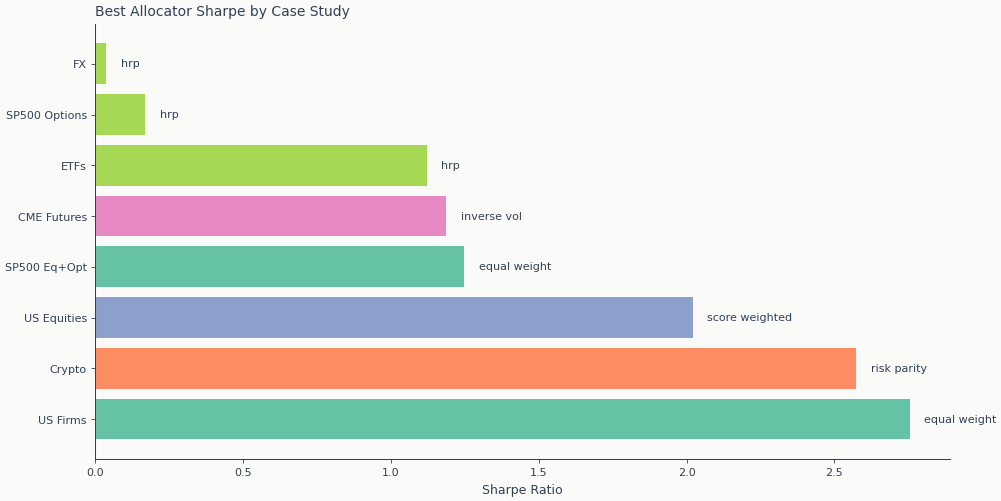

In [6]:
best_data = best_per_cs.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {}
color_cycle = plt.cm.Set2.colors
for i, alloc in enumerate(best_data["allocator"].unique()):
    colors_map[alloc] = color_cycle[i % len(color_cycle)]

bars = ax.barh(
    best_data["display_name"],
    best_data["sharpe"],
    color=[colors_map.get(a, "steelblue") for a in best_data["allocator"]],
)
ax.set_xlabel("Sharpe Ratio")
ax.set_title("Best Allocator Sharpe by Case Study")
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

for bar, alloc in zip(bars, best_data["allocator"], strict=False):
    x_pos = bar.get_width()
    ax.text(
        x_pos + 0.05 if x_pos >= 0 else x_pos - 0.05,
        bar.get_y() + bar.get_height() / 2,
        alloc.replace("_", " "),
        va="center",
        ha="left" if x_pos >= 0 else "right",
        fontsize=8,
    )

fig.show()

**Interpretation**: The bar chart makes the cross-dataset heterogeneity immediately visible.
Case studies with strong signals show positive Sharpe regardless of allocator choice.
Case studies with weak signals show negative Sharpe across all allocators — no allocation
method can rescue a failing signal.

## Equal-Weight Baseline vs Best Allocator

How much does allocation choice improve over the simplest baseline?

In [7]:
ew_sharpes = (
    comparison.filter(pl.col("allocator") == "equal_weight")
    .group_by("case_study")
    .agg(ew_sharpe=pl.col("sharpe").max())
)

best_sharpes = (
    comparison.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", best_sharpe=pl.col("sharpe"), best_allocator=pl.col("allocator"))
)

improvement = (
    best_sharpes.join(ew_sharpes, on="case_study", how="left")
    .with_columns(
        display_name=pl.col("case_study").replace(SHORT_NAMES),
        sharpe_diff=pl.col("best_sharpe") - pl.col("ew_sharpe"),
    )
    .with_columns(
        pct_improvement=pl.when(pl.col("ew_sharpe").abs() > 0.001)
        .then((pl.col("sharpe_diff") / pl.col("ew_sharpe").abs()) * 100)
        .otherwise(0.0),
    )
    .sort("sharpe_diff", descending=True)
)
print("Sharpe improvement from equal-weight to best allocator:\n")
improvement.select(
    "display_name", "ew_sharpe", "best_sharpe", "best_allocator", "sharpe_diff", "pct_improvement"
)

Sharpe improvement from equal-weight to best allocator:



display_name,ew_sharpe,best_sharpe,best_allocator,sharpe_diff,pct_improvement
str,f64,f64,str,f64,f64
"""Crypto""",2.090074,2.574056,"""risk_parity""",0.483982,23.156209
"""ETFs""",0.81293,1.120843,"""hrp""",0.307912,37.876833
"""CME Futures""",0.956424,1.187263,"""inverse_vol""",0.230838,24.135525
"""US Equities""",1.867508,2.020147,"""score_weighted""",0.152638,8.173367
"""FX""",-0.085029,0.037126,"""hrp""",0.122155,143.662423
"""SP500 Options""",0.15982,0.168183,"""hrp""",0.008363,5.232815
"""SP500 Eq+Opt""",1.246553,1.246553,"""equal_weight""",0.0,0.0
"""US Firms""",2.754197,2.754197,"""equal_weight""",0.0,0.0


**Interpretation**: This table shows that allocator choice usually changes the
result by less than the signal itself. The gains over equal weight are material
in a few datasets, but they are rarely universal.

## Allocator Performance Heatmap

Visualize which allocators appear across case studies and their relative performance.

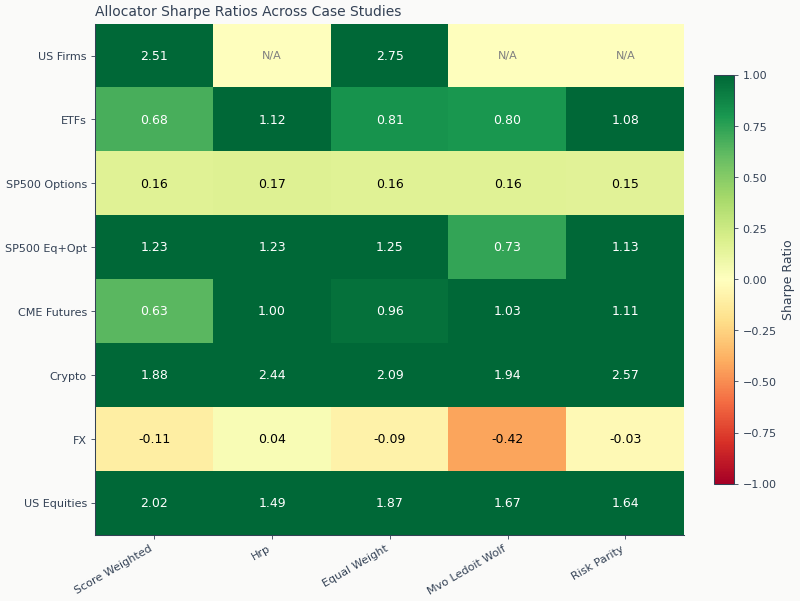

In [8]:
# Find the most common allocators
alloc_counts = comparison.group_by("allocator").agg(n=pl.len()).sort("n", descending=True)
common_allocators = alloc_counts.head(5)["allocator"].to_list()

heatmap_data = (
    comparison.filter(pl.col("allocator").is_in(common_allocators))
    .group_by("display_name", "allocator")
    .agg(sharpe=pl.col("sharpe").max())
    .pivot(on="allocator", index="display_name", values="sharpe")
)

cs_names = heatmap_data["display_name"].to_list()
alloc_cols = [c for c in heatmap_data.columns if c != "display_name"]
data_matrix = heatmap_data.select(alloc_cols).to_numpy()
mask = np.isnan(data_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    np.where(mask, 0, data_matrix),
    cmap="RdYlGn",
    aspect="auto",
    vmin=-1,
    vmax=1,
)

for i in range(len(cs_names)):
    for j in range(len(alloc_cols)):
        val = data_matrix[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)
        else:
            ax.text(j, i, "N/A", ha="center", va="center", color="gray", fontsize=8)

ax.set_xticks(range(len(alloc_cols)))
ax.set_xticklabels([a.replace("_", " ").title() for a in alloc_cols], rotation=30, ha="right")
ax.set_yticks(range(len(cs_names)))
ax.set_yticklabels(cs_names)
ax.set_title("Allocator Sharpe Ratios Across Case Studies")
fig.colorbar(im, ax=ax, label="Sharpe Ratio", shrink=0.8)
fig.subplots_adjust(left=0.18, right=0.92, top=0.9, bottom=0.2)
fig.show()

**Interpretation**: The heatmap reveals that no single allocator dominates
across all case studies. Missing cells (N/A) indicate that not every
allocator was tested on every dataset — strategy-specific constraints
(e.g., long-only, no shorting) exclude certain methods. Green cells
(Sharpe > 0) cluster around a few case studies with strong underlying
signals, confirming that the upstream prediction quality matters more
than the allocation method. Red or near-zero cells indicate that even
the best allocator cannot rescue a weak signal.

## Signal Strength vs Allocation Impact

Does allocation choice matter more when the underlying signal is strong?
We compare the spread between best and worst allocator Sharpe per case study.

In [9]:
spread_df = (
    comparison.group_by("case_study")
    .agg(
        display_name=pl.col("display_name").first(),
        best_sharpe=pl.col("sharpe").max(),
        worst_sharpe=pl.col("sharpe").min(),
        n_allocators=pl.col("allocator").n_unique(),
    )
    .with_columns(spread=pl.col("best_sharpe") - pl.col("worst_sharpe"))
    .sort("spread", descending=True)
)
print("Allocator Sharpe spread (best - worst) per case study:\n")
spread_df.select("display_name", "best_sharpe", "worst_sharpe", "spread", "n_allocators")

Allocator Sharpe spread (best - worst) per case study:



display_name,best_sharpe,worst_sharpe,spread,n_allocators
str,f64,f64,f64,u32
"""Crypto""",2.574056,1.881573,0.692483,7
"""CME Futures""",1.187263,0.628271,0.558992,7
"""US Equities""",2.020147,1.489765,0.530381,7
"""SP500 Eq+Opt""",1.246553,0.73152,0.515033,7
"""FX""",0.037126,-0.422593,0.459719,7
"""ETFs""",1.120843,0.676976,0.443867,7
"""US Firms""",2.754197,2.505178,0.249019,3
"""SP500 Options""",0.168183,0.149057,0.019126,6


**Interpretation**: The best-minus-worst spread is the cleanest summary of
allocator sensitivity. Wide spreads indicate that portfolio construction is
load-bearing for that dataset, while tight spreads indicate that upstream
signal quality dominates method choice.

## Summary Statistics

In [10]:
positive = spread_df.filter(pl.col("best_sharpe") > 0).height
total = spread_df.height

print(f"""
=== Cross-Dataset Allocation Summary ===
Case studies loaded:    {n_cs}
Total allocator combos: {len(comparison)}

--- Signal Quality ---""")

for row in spread_df.iter_rows(named=True):
    cs = row["display_name"]
    best = row["best_sharpe"]
    spread = row["spread"]
    print(f"  {cs:20s}  Best SR: {best:+.2f}  Spread: {spread:.3f}")

print("\n--- Key Findings ---")
print(f"- Positive best Sharpe in {positive}/{total} case studies")
if spread_df.height > 0:
    widest = spread_df.row(0, named=True)
    tightest = spread_df.sort("spread").row(0, named=True)
    print(
        f"- Largest allocation sensitivity: {widest['display_name']} (spread={widest['spread']:.3f})"
    )
    print(
        f"- Smallest allocation sensitivity: {tightest['display_name']} "
        f"(spread={tightest['spread']:.3f})"
    )
print("- No single allocator has the highest Sharpe in every case study")


=== Cross-Dataset Allocation Summary ===
Case studies loaded:    8
Total allocator combos: 51

--- Signal Quality ---
  Crypto                Best SR: +2.57  Spread: 0.692
  CME Futures           Best SR: +1.19  Spread: 0.559
  US Equities           Best SR: +2.02  Spread: 0.530
  SP500 Eq+Opt          Best SR: +1.25  Spread: 0.515
  FX                    Best SR: +0.04  Spread: 0.460
  ETFs                  Best SR: +1.12  Spread: 0.444
  US Firms              Best SR: +2.75  Spread: 0.249
  SP500 Options         Best SR: +0.17  Spread: 0.019

--- Key Findings ---
- Positive best Sharpe in 8/8 case studies
- Largest allocation sensitivity: Crypto (spread=0.692)
- Smallest allocation sensitivity: SP500 Options (spread=0.019)
- No single allocator has the highest Sharpe in every case study


## Uplift Breadth: Is Allocation Improvement Broad or Narrow?

A practitioner needs to know: is the allocation improvement driven by
one lucky combination, or do most allocators improve over the baseline?
Narrow uplift (only one allocator helps) is less reliable than broad
uplift (most allocators improve).

In [11]:
breadth_rows = []
for cs_id in comparison["case_study"].unique().sort().to_list():
    cs_data = comparison.filter(pl.col("case_study") == cs_id)
    ew_row = cs_data.filter(pl.col("allocator") == "equal_weight")
    if ew_row.is_empty():
        continue
    ew_sr = ew_row["sharpe"].max()
    non_ew = cs_data.filter(pl.col("allocator") != "equal_weight")
    if non_ew.is_empty():
        continue
    n_better = non_ew.filter(pl.col("sharpe") > ew_sr).height
    n_total = non_ew.height
    breadth_rows.append(
        {
            "case_study": cs_id,
            "display_name": SHORT_NAMES.get(cs_id, cs_id),
            "ew_sharpe": round(ew_sr, 3),
            "n_allocators_tested": n_total,
            "n_beat_ew": n_better,
            "pct_beat_ew": round(100 * n_better / n_total, 0) if n_total > 0 else 0,
            "breadth": "broad"
            if n_better / max(n_total, 1) > 0.5
            else "moderate"
            if n_better / max(n_total, 1) > 0.25
            else "narrow",
        }
    )

breadth = (
    pl.DataFrame(breadth_rows).sort("pct_beat_ew", descending=True)
    if breadth_rows
    else pl.DataFrame()
)

In [12]:
if not breadth.is_empty():
    print("=== Allocation Uplift Breadth ===")
    print(
        breadth.select(
            "display_name",
            "ew_sharpe",
            "n_beat_ew",
            "n_allocators_tested",
            "pct_beat_ew",
            "breadth",
        )
    )

    n_broad = breadth.filter(pl.col("breadth") == "broad").height
    n_narrow = breadth.filter(pl.col("breadth") == "narrow").height
    print(f"\nBroad uplift: {n_broad}/{breadth.height}")
    print(f"Narrow uplift: {n_narrow}/{breadth.height}")

=== Allocation Uplift Breadth ===
shape: (8, 6)
┌───────────────┬───────────┬───────────┬─────────────────────┬─────────────┬──────────┐
│ display_name  ┆ ew_sharpe ┆ n_beat_ew ┆ n_allocators_tested ┆ pct_beat_ew ┆ breadth  │
│ ---           ┆ ---       ┆ ---       ┆ ---                 ┆ ---         ┆ ---      │
│ str           ┆ f64       ┆ i64       ┆ i64                 ┆ f64         ┆ str      │
╞═══════════════╪═══════════╪═══════════╪═════════════════════╪═════════════╪══════════╡
│ CME Futures   ┆ 0.956     ┆ 5         ┆ 6                   ┆ 83.0        ┆ broad    │
│ Crypto        ┆ 2.09      ┆ 4         ┆ 6                   ┆ 67.0        ┆ broad    │
│ ETFs          ┆ 0.813     ┆ 4         ┆ 6                   ┆ 67.0        ┆ broad    │
│ FX            ┆ -0.085    ┆ 3         ┆ 6                   ┆ 50.0        ┆ moderate │
│ SP500 Options ┆ 0.16      ┆ 1         ┆ 5                   ┆ 20.0        ┆ narrow   │
│ US Equities   ┆ 1.868     ┆ 1         ┆ 6                   

**Interpretation**: "Broad" means most non-EW allocators improve over
equal weight — the uplift is insensitive to allocator choice. "Narrow"
means only one or two allocators exceed the baseline — the improvement
depends on picking the right method. This matters for Ch20: broad uplift
is more trustworthy as a real improvement; narrow uplift could be
selection bias.

## When Does Allocation Optimization Help?

The previous sections show that allocation uplift varies across datasets.
Here we ask the structural question: **what predicts whether optimization
helps?** We hypothesize two factors:

- **Signal strength** (EW baseline Sharpe): When the signal is strong,
  most allocators produce positive returns — optimization adds little.
- **Universe size**: In broad universes, allocation determines
  concentration; in narrow ones, top-$k$ selection dominates.

The scatter below tests this hypothesis.

In [13]:
# Build structural features for the "when MVO helps" analysis.
# The EW baseline comes from Ch16 (signal stage), not Ch17 allocators.
ch16_raw = load_chapter_backtests("ch16", case_studies=CS_LIST, metrics=["sharpe"])
ch16_ew = (
    ch16_raw.with_columns(
        allocator=pl.col("spec_json").map_elements(extract_allocator, return_dtype=pl.Utf8),
    )
    .filter(pl.col("allocator") == "equal_weight")
    .sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", ew_sharpe=pl.col("sharpe"))
)

UNIVERSE_SIZES = {
    "etfs": 64,
    "crypto_perps_funding": 19,
    "nasdaq100_microstructure": 114,
    "sp500_equity_option_analytics": 634,
    "us_firm_characteristics": 2250,
    "fx_pairs": 20,
    "cme_futures": 30,
    "sp500_options": 480,
    "us_equities_panel": 311,
}

In [14]:
# Best allocator Sharpe per CS from Ch17
best_alloc = (
    comparison.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", best_sharpe=pl.col("sharpe"))
)

mvo_data = best_alloc.join(ch16_ew, on="case_study", how="inner").with_columns(
    display_name=pl.col("case_study").replace(SHORT_NAMES),
    uplift=pl.col("best_sharpe") - pl.col("ew_sharpe"),
)

mvo_rows = []
for row in mvo_data.iter_rows(named=True):
    mvo_rows.append(
        {
            "case_study": row["case_study"],
            "display_name": row["display_name"],
            "ew_sharpe": float(row["ew_sharpe"]),
            "best_sharpe": float(row["best_sharpe"]),
            "uplift": float(row["uplift"]),
            "universe_size": UNIVERSE_SIZES.get(row["case_study"], 0),
        }
    )

mvo_df = pl.DataFrame(mvo_rows)

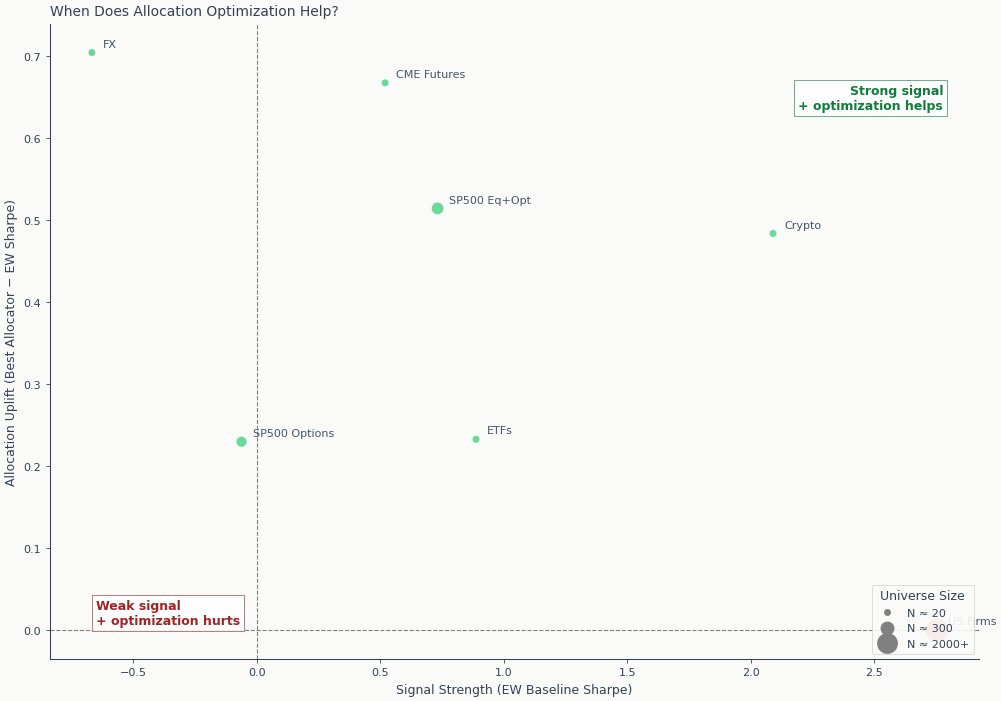

In [15]:
# Scatter plot: signal strength vs allocation uplift
if mvo_df.height >= 3:
    fig, ax = plt.subplots(figsize=(10, 7))

    ew_vals = mvo_df["ew_sharpe"].to_list()
    uplift_vals = mvo_df["uplift"].to_list()
    sizes = [max(30, n / 8) for n in mvo_df["universe_size"].to_list()]
    names = mvo_df["display_name"].to_list()

    # Color by whether uplift is positive
    colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in uplift_vals]

    ax.scatter(ew_vals, uplift_vals, s=sizes, c=colors, alpha=0.7, edgecolors="white", zorder=5)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

    for name, x, y in zip(names, ew_vals, uplift_vals, strict=False):
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(8, 4),
            fontsize=8,
            color="#475569",
        )

    ax.set_xlabel("Signal Strength (EW Baseline Sharpe)")
    ax.set_ylabel("Allocation Uplift (Best Allocator − EW Sharpe)")
    ax.set_title("When Does Allocation Optimization Help?")

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(
        xlim[1] * 0.95,
        ylim[1] * 0.9,
        "Strong signal\n+ optimization helps",
        ha="right",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#0f7c3a",
        bbox={"facecolor": "white", "edgecolor": "#0f7c3a", "alpha": 0.85, "pad": 3},
    )
    ax.text(
        xlim[0] + (xlim[1] - xlim[0]) * 0.05,
        ylim[0] + (ylim[1] - ylim[0]) * 0.05,
        "Weak signal\n+ optimization hurts",
        ha="left",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#a32222",
        bbox={"facecolor": "white", "edgecolor": "#a32222", "alpha": 0.85, "pad": 3},
    )

    from matplotlib.lines import Line2D

    size_legend = [
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=5, label="N ≈ 20"),
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=10, label="N ≈ 300"),
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=15, label="N ≈ 2000+"),
    ]
    ax.legend(
        handles=size_legend,
        title="Universe Size",
        loc="lower right",
        fontsize=8,
        frameon=True,
        framealpha=0.9,
    )

    fig.show()
else:
    print("Insufficient data for MVO diagnostic scatter.")

**Finding**: The scatter reveals a clear pattern. Case studies with
**strong EW baselines** (positive Sharpe) see modest allocation uplift —
the signal dominates portfolio construction. Case studies with **weak
signals** (near-zero or negative EW Sharpe) show the largest swings from
allocation choice, but often in the wrong direction: optimization
amplifies noise when the underlying signal is unreliable.

The bubble sizes show that **universe size** is a secondary factor.
Narrow universes (crypto, FX) leave little room for allocators to
differentiate. Broad universes (US Firms, S&P 500) create more scope
for optimization — but also more scope for overfitting to noise.

**Practical takeaway**: If your EW baseline Sharpe is above ~0.5,
allocator choice is secondary. Below that, allocation can help
or hurt — but never rescues a failing signal.

## Key Takeaways

1. **The highest-Sharpe allocator varies by case study.** No single
   allocator has the highest Sharpe across all eight case studies.
2. **Equal weight is competitive across most case studies.** It is the
   highest-Sharpe allocator in two (US Firms and S&P 500 Eq+Opt) and
   sits within ~0.25 Sharpe of the top allocator in four others
   (CME Futures, US Equities, FX Pairs, S&P 500 Options). Across the eight
   case studies the best-allocator wins distribute as HRP (3: ETFs,
   S&P 500 Options, FX Pairs), equal_weight (2), risk_parity (1: Crypto),
   score_weighted (1: US Equities), and inverse_vol (1: CME Futures);
   MVO Ledoit-Wolf and conformal_weighted are top in none.
3. **Allocation uplift is often narrow**: In most case studies, only a
   minority of allocators exceed equal weight — the improvement depends
   on choosing the right method, not on allocation being universally
   helpful.
4. **Signal quality is the dominant driver**: Allocation does not turn a
   failing signal into a profitable strategy in any of the eight case studies.
   Its marginal value is strongly dataset-dependent and never substitutes
   for a strong forecasting signal.
5. **When MVO helps**: Allocation optimization adds most value when the
   baseline signal is moderate (not too strong, not too weak) and the
   universe is broad enough to benefit from concentration choices.

**Next**: [`06_cost_survival`](06_cost_survival.ipynb) translates the same
allocator choices into cost-adjusted performance.